<div style="font-family: Calibri; background-color: #ccd5ae; padding: 10px 10px;">
    <h2>XGBoost</h2>
    <hr>
    <h4>Ensemble - (SMOTETomek + CatBoostClassifier)
</div>

In [57]:
import pandas as pd
import numpy as np
import warnings
from sklearn import set_config
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from scripts.plot_tetha import plot_model
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, make_scorer, confusion_matrix, fbeta_score
from sklearn.pipeline import Pipeline

In [58]:
%load_ext autoreload
%autoreload 2
from scripts.scores import calc_predict_proba, calc_scores, confusion_matrix_display, print_evaluation
from scripts.decision_tree import determine_parameter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
warnings.filterwarnings("ignore") 
set_config(display='diagram')
pd.options.display.precision=3
pd.set_option('display.float_format', lambda x: '%.3f' % x)

<div style="font-family: Calibri; background-color: #faedcd; padding: 5px;">
    <h2>1. Loading Train and Test dataset</h2>
</div>

In [60]:
df = pd.read_csv("data/train.csv" )
df.shape

(255347, 18)

In [61]:
X = df.drop(columns=['Default', 'LoanID', 'DTIRatio', 'CreditScore'])
y = df['Default']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape,  y_train.shape, y_test.shape)

(204277, 14) (51070, 14) (204277,) (51070,)


<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>2. Column Transformation</h2>
</div>

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

<div style="font-family: Calibri; background-color: #fefae0; padding: 3px 3px 3px 10px;">
    <h3>Univariate Analysis - Conclusion (Recap)</h3>    
    <ul>
            <li>HasCoSigner, HasDependents, HasMortgage are binary fields</li>
            <li>Education, EmploymentType, LoanPurpose, MaritalStatus are categorical data</li>
    </ul>        
    <h4>Transformation is done external to pipeline to avoid the redundent step In GridSearchCV
    </h4>
</div>

In [64]:
numerical_features = X_train.select_dtypes(exclude='object').columns.tolist()
categorial_features = X_train.select_dtypes(include='object').columns.tolist()

In [65]:
transformer = ColumnTransformer(
    [
        ('Binary', OneHotEncoder(drop='if_binary'), ['HasCoSigner', 'HasDependents', 'HasMortgage']),
        ('multi_category', OneHotEncoder(),  ['Education', 'EmploymentType', 'MaritalStatus']),
        ('Loan_category', OneHotEncoder(categories = [['Business', 'Home']], handle_unknown='ignore'), ['LoanPurpose']), 
    ], remainder=Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=True)),
            ('scaler', MinMaxScaler())
        ])
)

In [66]:
X_train = transformer.fit_transform(X_train)

In [67]:
X_test = transformer.transform(X_test)

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>3. SMOTE+Tomek</h2>
</div>

In [68]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [69]:
# Initialize the SMOTE
rus = SMOTETomek(random_state=42)

# Fit and apply the undersampling
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [70]:
# The resampled data is now balanced
print("Shape of X before undersampling:", X_train.shape)
print("Shape of X after undersampling:", X_resampled.shape)
print("Value counts before undersampling:", pd.Series(y_train).value_counts())
print("Value counts after undersampling:", pd.Series(y_resampled).value_counts())

Shape of X before undersampling: (204277, 52)
Shape of X after undersampling: (360328, 52)
Value counts before undersampling: Default
0    180524
1     23753
Name: count, dtype: int64
Value counts after undersampling: Default
0    180164
1    180164
Name: count, dtype: int64


In [71]:
X_train, y_train = X_resampled, y_resampled

<hr>
<div style="font-family: Calibri; background-color: #faedcd; padding: 5px 5px 5px 5px;">
    <h2>4. CatBoostClassifier</h2>
</div>

In [72]:
import xgboost as xgb
from catboost import CatBoostClassifier
from skopt import BayesSearchCV

In [73]:
scoring=make_scorer(fbeta_score, beta=2, pos_label=1)

In [74]:
model = CatBoostClassifier(class_weights={0:1, 1:9}, 
                           random_state=42, 
                           verbose=False,                           
                           l2_leaf_reg=5,
                           eval_metric = 'LogLikelihoodOfPrediction')

In [75]:
model.fit(X_train, y_train)

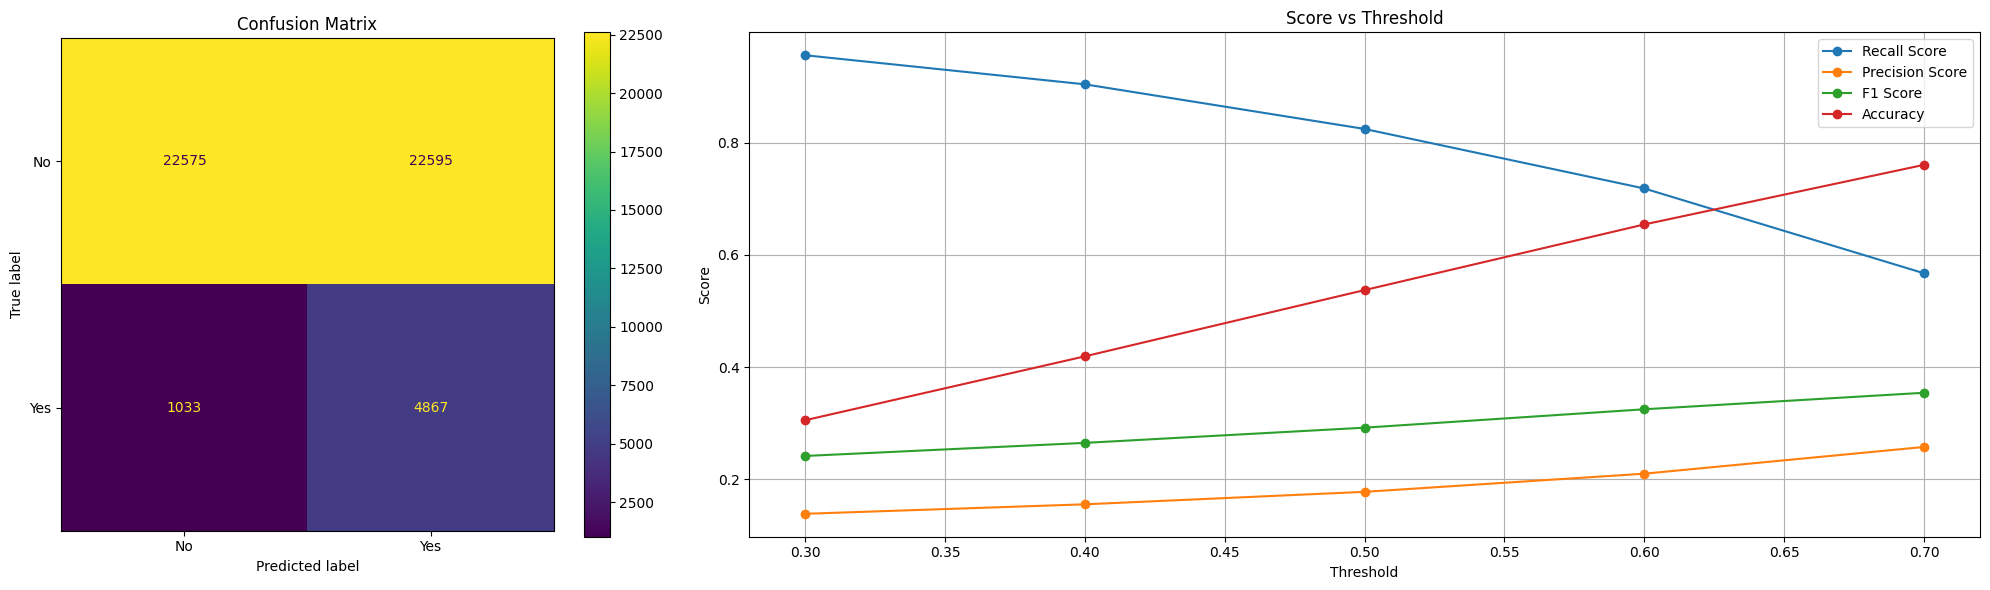

,Score,Percentage
0,Training Accuracy,74.10%
1,Test Accuracy,53.73%
2,Recall Score,56.73%
3,Precision Score,25.73%
4,Accuracy Score,76.09%
5,F1 Score,35.41%
6,ROC AUC Score,66.23%


In [76]:
scores_df, threshold_df = print_evaluation(model, X_train, y_train, X_test, y_test)
scores_df

In [77]:
threshold_df

,recall,precision,f1-score,accuracy
0.300,0.956,0.138,0.241,0.305
0.400,0.905,0.155,0.265,0.419
0.500,0.825,0.177,0.292,0.537
0.600,0.719,0.210,0.325,0.654
0.700,0.567,0.257,0.354,0.761
